<a href="https://colab.research.google.com/github/Bachbean/Predicting-the-Unpredictable/blob/main/scripts/L63_ami.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


First local minimum:
Lag = 16
AMI = 0.7018640146358154


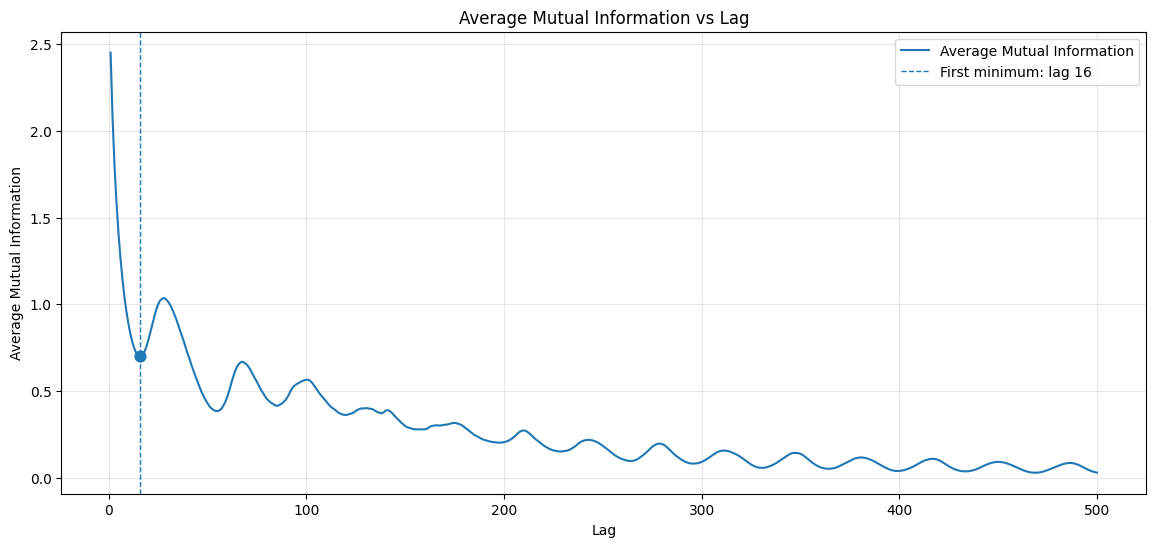

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD DATA FROM TXT FILE
# ============================================================

# Replace this with your actual file name
file_name = "https://raw.githubusercontent.com/Bachbean/Predicting-the-Unpredictable/refs/heads/main/scripts/L63_x.txt"

data = np.loadtxt(file_name, dtype=np.float64)


# ============================================================
# 2. CHOOSE SETTINGS
# ============================================================

# Maximum lag to test
max_lag = 500

# Number of bins used to estimate probabilities
# You can experiment with this later.
num_bins = 32


# ============================================================
# 3. FUNCTION TO CALCULATE MUTUAL INFORMATION
# ============================================================

def mutual_information(x, y, bins):
    """
    Estimate mutual information I(X;Y) using a 2D histogram.
    """

    # Joint histogram
    joint_hist, _, _ = np.histogram2d(x, y, bins=bins)

    # Convert counts into probabilities
    joint_prob = joint_hist / np.sum(joint_hist)

    # Marginal probabilities
    prob_x = np.sum(joint_prob, axis=1)
    prob_y = np.sum(joint_prob, axis=0)

    # Calculate mutual information
    mi = 0.0

    for i in range(len(prob_x)):
        for j in range(len(prob_y)):

            if joint_prob[i, j] > 0 and prob_x[i] > 0 and prob_y[j] > 0:

                mi += joint_prob[i, j] * np.log(
                    joint_prob[i, j] /
                    (prob_x[i] * prob_y[j])
                )

    return mi


# ============================================================
# 4. CALCULATE AMI FOR EACH LAG
# ============================================================

lags = np.arange(1, max_lag + 1)

ami_values = []

for lag in lags:

    # x(t)
    x = data[:-lag]

    # x(t + lag)
    y = data[lag:]

    mi = mutual_information(
        x,
        y,
        bins=num_bins
    )

    ami_values.append(mi)

ami_values = np.array(ami_values)


# ============================================================
# 5. PRINT AMI VALUES
# ============================================================

#print("\nAverage Mutual Information values:")

#for lag, value in zip(lags, ami_values):
#    print(f"Lag {lag}: {value:.10f}")


# ============================================================
# 6. FIND FIRST LOCAL MINIMUM
# ============================================================

first_minimum = None

for i in range(1, len(ami_values) - 1):

    if (
        ami_values[i] < ami_values[i - 1]
        and
        ami_values[i] < ami_values[i + 1]
    ):

        first_minimum = lags[i]
        break


if first_minimum is not None:

    index = first_minimum - 1

    print("\nFirst local minimum:")
    print("Lag =", first_minimum)
    print("AMI =", ami_values[index])

else:

    print("\nNo local minimum found in the tested lag range.")


# ============================================================
# 7. PLOT AMI
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    lags,
    ami_values,
    linewidth=1.5,
    label="Average Mutual Information"
)


# Mark first local minimum
if first_minimum is not None:

    index = first_minimum - 1

    plt.axvline(
        x=first_minimum,
        linestyle="--",
        linewidth=1,
        label=f"First minimum: lag {first_minimum}"
    )

    plt.scatter(
        first_minimum,
        ami_values[index],
        s=60
    )


plt.xlabel("Lag")
plt.ylabel("Average Mutual Information")
plt.title("Average Mutual Information vs Lag")

plt.grid(alpha=0.3)
plt.legend()

plt.show()
